In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt


In [3]:
def f(mPoints):
    # Function recieves 2d array of coordinates in shape 2xmany, each column is a separate point, 
    vX = mPoints[0, :] # retrieve of x coordinates
    vY = mPoints[1, :] # retrieve of y coordinates

    # function return scalar according to x^2 + 10*y^2
    vZ = vX **2 + 10 * vY **2
    return vZ

$
f : \mathbb{R}^2 \to \mathbb{R}
$

$
f(x,y) = x^2 + 10y^2
$
The gradient of the function is

$$
\nabla f(x,y) =
\begin{bmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y}
\end{bmatrix}
=
\begin{bmatrix}
2x \\
20y
\end{bmatrix}
$$

In [4]:
def grad_unit_vector(v_point):
    # function calculates analyically and manually the gradient unit vector in a given point (x0, y0)
    der_x = 2 * v_point[0] # partial derivative in x direction
    der_y = 20 * v_point[1] # partial derivative in y direction
    v_grad = np.array([der_x, der_y]) # Putting in one vector
    norm_v_grad = np.linalg.norm(v_grad) # calculation of norma
    v_grad_unit = v_grad / norm_v_grad # gradient unit vector
    return v_grad_unit

In [5]:
vX = np.linspace(-3, 3, 101) # 
mXX, mYY = np.meshgrid(vX, vX)
mPoints = np.array([mXX.flatten(), mYY.flatten()])
vZ = f(mPoints)
mZ = vZ.reshape(mXX.shape) # surface points

In [6]:
# i want to choose random point from Points
rand_column = np.random.randint(mPoints.shape[1]) # selection of random column from Points 2d-array
xy_point = mPoints[:, rand_column].reshape(-1, 1) # single points in 2d as a column vector
z_point = f(xy_point) # surface value for chosen [x, y].T point
print(f'The coordinates of selected points in 3D:({xy_point[0][0].round(2)}, {xy_point[1][0].round(2)}, {z_point[0].round(2)})')

The coordinates of selected points in 3D:(0.54, -0.48, 2.6)


In [7]:
# now i just want to find next point in the direction of gradient decsent
step = 0.4
next_xy_point = xy_point - grad_unit_vector(xy_point) * step # finding of (x, y) coordinate
next_z_point = f(next_xy_point) # finding of z coordinate

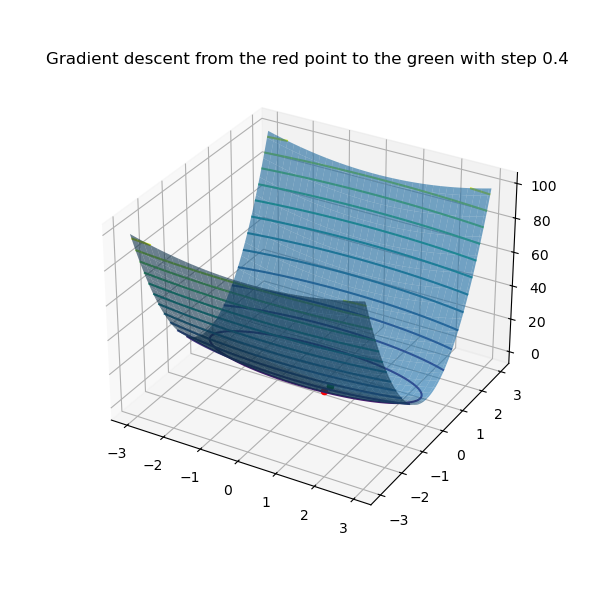

In [8]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(mXX, mYY, mZ, alpha = 0.6, edgecolor='none')
ax.contour(mXX, mYY, mZ, levels=12)
x0 = xy_point[0]
y0 = xy_point[1]
ax.scatter(x0, y0, z_point, marker = 'o', c='r')
ax.scatter(next_xy_point[0], next_xy_point[1], next_z_point,marker = 'o', c='green')
ax.set_title(f'Gradient descent from the red point to the green with step {step}')
plt.show()

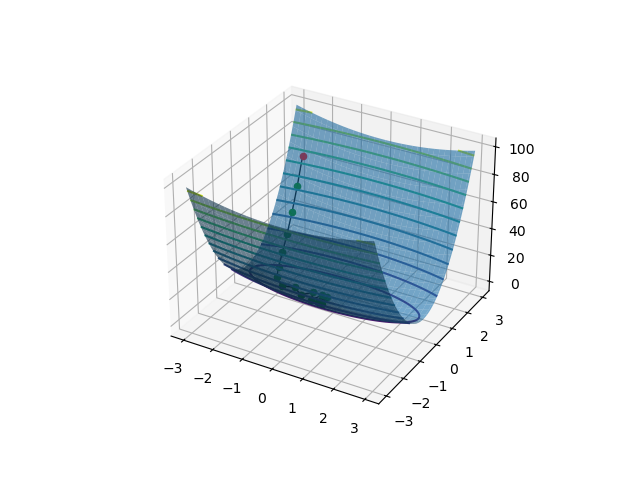

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(mXX, mYY, mZ, alpha = 0.6, edgecolor='none')
ax.contour(mXX, mYY, mZ, levels=12)
initial_point_x_y = np.array([[-2.5], [2.5]])
initial_point_z = f(initial_point_x_y)
ax.scatter(initial_point_x_y[0], initial_point_x_y[1], initial_point_z, 'o', c='r')

step = 0.4
num_steps = 15

for i in range(num_steps):
    new_xy_point = initial_point_x_y - grad_unit_vector(initial_point_x_y) * step
    ax.scatter(new_xy_point[0], new_xy_point[1], f(new_xy_point), 'o', c='green')
    ax.plot([initial_point_x_y[0], new_xy_point[0]],
            [initial_point_x_y[1], new_xy_point[1]],
            [f(initial_point_x_y), f(new_xy_point)], c = 'k', lw=1)
    initial_point_x_y = new_xy_point

plt.show()
